## DeepHit - Competing Risks Survival Model

Reframes the problem from monthly classification (extreme imbalance) to survival analysis:
- **Input**: one row per loan with 9 static features (loan/market — no borrower features)
- **Output**: probability of default/prepay at each discrete time step (1-36 months)
- **Handles**: censoring, competing risks (default vs prepay), class imbalance naturally
- **Features**: BorrowerRate, FED rate, T-bill rate, unemployment rate, APR-FED spread, APR-T-bill spread, loan amount (log), Term, monthly payment
- **Architecture**: 128→64→32 MLP (14K params), alpha=0.5, sigma=0.1

In [1]:
# ===== 1. DATA PREP: Loan-level survival format =====
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('../data/prosperLoanData.csv')
fed_df = pd.read_csv('../data/FEDFUNDS.csv')
tb3ms_df = pd.read_csv('../data/TB3MS.csv')
unrate_df = pd.read_csv('../data/UNRATE.csv')

# Clean dates
df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')

# Remove cancelled loans
df = df[~df['LoanStatus'].isin(['Cancelled'])]

# Identify prepaid loans
df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

# Event type: 0=censored, 1=default, 2=prepay
def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

# Duration: months from origination to event or last observation
as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

# FED rate at origination
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

# T-bill rate at origination
tb3ms_df['observation_date'] = pd.to_datetime(tb3ms_df['observation_date'])
tb3ms_monthly = tb3ms_df.set_index('observation_date').resample('MS').first().ffill()
tb3ms_dict = tb3ms_monthly['TB3MS'].to_dict()
df['tb3ms_at_orig'] = df['orig_month'].map(tb3ms_dict)

# Unemployment rate at origination
unrate_df['observation_date'] = pd.to_datetime(unrate_df['observation_date'])
unrate_monthly = unrate_df.set_index('observation_date').resample('MS').first().ffill()
unrate_dict = unrate_monthly['UNRATE'].to_dict()
df['unrate_at_orig'] = df['orig_month'].map(unrate_dict)

# ---- Feature engineering (loan/market features only — no borrower features) ----
df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['apr_tbill_spread'] = df['BorrowerRate'] - df['tb3ms_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['monthly_payment'] = df['MonthlyLoanPayment']

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'tb3ms_at_orig', 'unrate_at_orig',
    'apr_fed_spread', 'apr_tbill_spread',
    'loan_amount_log', 'Term', 'monthly_payment'
]

surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0]

print(f'Loans: {len(surv_df):,}')
print(f'Events: {surv_df["event"].value_counts().to_dict()}')
print(f'Duration range: {surv_df["duration"].min()} - {surv_df["duration"].max()}')
print(f'Features: {len(feature_cols)}')
print(f'Year range: {surv_df["LoanOriginationDate"].dt.year.min()} - {surv_df["LoanOriginationDate"].dt.year.max()}')

Loans: 113,924
Events: {0: 69435, 2: 27480, 1: 17009}
Duration range: 1 - 36
Features: 9
Year range: 2005 - 2014


In [2]:
# ===== 2. TRAIN/VAL/TEST SPLIT (temporal, matching Morgan's RF) =====
# Train: 2005-2010 | Validate: 2011 | Test: 2012-2014
# 1-year gap between train and test to prevent data leakage
from sklearn.preprocessing import StandardScaler

train = surv_df[surv_df['LoanOriginationDate'].dt.year <= 2010].copy()
val   = surv_df[surv_df['LoanOriginationDate'].dt.year == 2011].copy()
test  = surv_df[surv_df['LoanOriginationDate'].dt.year >= 2012].copy()

# Standardize features (fit on train only)
scaler = StandardScaler()
x_train = scaler.fit_transform(train[feature_cols]).astype('float32')
x_val   = scaler.transform(val[feature_cols]).astype('float32')
x_test  = scaler.transform(test[feature_cols]).astype('float32')

# DeepHit targets
y_train_dur = train['duration'].values
y_train_evt = train['event'].values
y_val_dur   = val['duration'].values
y_val_evt   = val['event'].values
y_test_dur  = test['duration'].values
y_test_evt  = test['event'].values

print(f'Train (≤2010): {len(train):,} | Val (2011): {len(val):,} | Test (≥2012): {len(test):,}')
print(f'Train events: { {k: v for k, v in zip(*np.unique(y_train_evt, return_counts=True))} }')
print(f'Val events:   { {k: v for k, v in zip(*np.unique(y_val_evt, return_counts=True))} }')
print(f'Test events:  { {k: v for k, v in zip(*np.unique(y_test_evt, return_counts=True))} }')

Train (≤2010): 36,626 | Val (2011): 11,228 | Test (≥2012): 66,070
Train events: {np.int64(0): np.int64(9576), np.int64(1): np.int64(11904), np.int64(2): np.int64(15146)}
Val events:   {np.int64(0): np.int64(4121), np.int64(1): np.int64(2145), np.int64(2): np.int64(4962)}
Test events:  {np.int64(0): np.int64(55738), np.int64(1): np.int64(2960), np.int64(2): np.int64(7372)}


In [3]:
# ===== 3. DEEPHIT MODEL =====
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

# Discretize durations into time bins
num_durations = 36
labtrans = LabTransDiscreteTime(num_durations)
y_train_dh = labtrans.fit_transform(y_train_dur.astype('float64'), y_train_evt.astype('float64'))
y_val_dh   = labtrans.transform(y_val_dur.astype('float64'), y_val_evt.astype('float64'))
y_test_dh  = labtrans.transform(y_test_dur.astype('float64'), y_test_evt.astype('float64'))

y_train_dh = (y_train_dh[0].astype("int64"), y_train_dh[1].astype("int64"))
y_val_dh   = (y_val_dh[0].astype("int64"), y_val_dh[1].astype("int64"))
y_test_dh  = (y_test_dh[0].astype("int64"), y_test_dh[1].astype("int64"))

in_features = x_train.shape[1]
num_risks = 2  # default + prepay

class DeepHitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, num_risks * labtrans.out_features),
        )

    def forward(self, x):
        return self.mlp(x).view(-1, num_risks, labtrans.out_features)

net = DeepHitNet()

model = DeepHit(
    net,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'Model params: {sum(p.numel() for p in net.parameters()):,}')
print(f'Input features: {in_features}')
print(f'Output shape: [batch, {num_risks}, {labtrans.out_features}]')
print(net)

Model params: 14,440
Input features: 9
Output shape: [batch, 2, 36]
DeepHitNet(
  (mlp): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=72, bias=True)
  )
)


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1862.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[1s / 1s],		train_loss: 2.4784,	val_loss: 2.4190
1:	[1s / 3s],		train_loss: 2.4147,	val_loss: 2.4234
2:	[1s / 5s],		train_loss: 2.3761,	val_loss: 2.5669
3:	[1s / 6s],		train_loss: 2.3477,	val_loss: 2.2939
4:	[1s / 8s],		train_loss: 2.3175,	val_loss: 2.1648
5:	[1s / 10s],		train_loss: 2.2837,	val_loss: 2.0843
6:	[1s / 12s],		train_loss: 2.2487,	val_loss: 1.9788
7:	[1s / 13s],		train_loss: 2.2096,	val_loss: 1.9441
8:	[1s / 15s],		train_loss: 2.1706,	val_loss: 1.8900
9:	[1s / 16s],		train_loss: 2.1324,	val_loss: 1.8360
10:	[1s / 18s],		train_loss: 2.0992,	val_loss: 1.8138
11:	[1s / 19s],		train_loss: 2.0682,	val_loss: 1.8380
12:	[1s / 21s],		train_loss: 2.0370,	val_loss: 1.7750
13:	[1s / 22s],		train_loss: 2.0103,	val_loss: 1.7478
14:	[1s / 24s],		train_loss: 1.9811,	val_loss: 1.7282
15:	[1s / 25s],		train_loss: 1.9536,	val_loss: 1.7143
16:	[1s / 27s],		train_loss: 1.9265,	val_loss: 1.7021
17:	[1s / 28s],		train_loss: 1.9028,	val_loss: 1.6933
18:	[1s / 30s],		train_loss: 1.8822,	val_lo

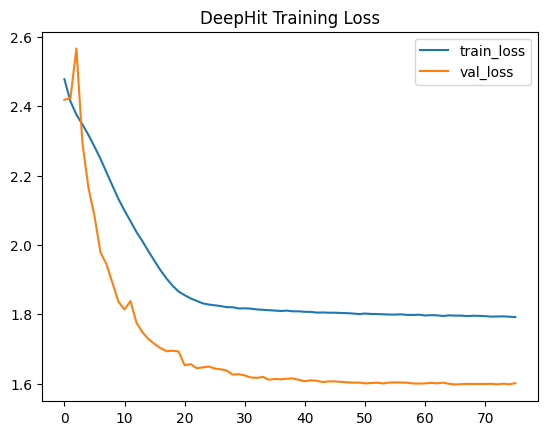

In [4]:
# ===== 4. TRAIN =====
batch_size = 512
epochs = 100

# Callbacks: early stopping on validation set (2011) + weight decay
callbacks = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

model.optimizer.set_lr(0.0005)

log = model.fit(
    x_train, y_train_dh,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    val_data=(x_val, y_val_dh),
    verbose=True
)

# Plot training loss
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
log.plot(ax=ax)
ax.set_title('DeepHit Training Loss')
plt.show()

In [5]:
# ===== 5. EVALUATE (on test set: 2012-2014) =====
from pycox.evaluation import EvalSurv

# Fix scipy compatibility (simps renamed to simpson in newer scipy)
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Get CIF (cumulative incidence functions) for each risk
cif = model.predict_cif(x_test)

# --- C-index ---
print('=== C-index (time-dependent) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    c_idx = ev.concordance_td()
    print(f'  {risk_name} C-index: {c_idx:.3f}')

# --- Brier Score ---
print('\n=== Integrated Brier Score ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    time_grid = np.linspace(1, 36, 36)
    ibs = ev.integrated_brier_score(time_grid)
    print(f'  {risk_name} IBS: {ibs:.4f} (lower is better)')

# --- Lift chart ---
print('\n=== Lift by Decile (at t=12 months) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    t12_idx = 11  # 0-indexed
    pred_risk = cif[risk_idx][t12_idx, :]
    actual_by_t12 = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)

    order = np.argsort(-pred_risk)  # highest risk first
    n = len(order)
    decile_size = n // 10
    baseline_rate = actual_by_t12.mean()

    print(f'  {risk_name} (baseline rate: {baseline_rate:.4f}):')
    for d in range(10):
        idx = order[d * decile_size:(d + 1) * decile_size]
        rate = actual_by_t12[idx].mean()
        lift = rate / baseline_rate if baseline_rate > 0 else 0
        bar = '#' * int(lift * 5)
        print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

print(f'\nCIF shape: {cif[0].shape} (time_steps x loans)')

=== C-index (time-dependent) ===
  Default C-index: 0.579
  Prepay C-index: 0.518

=== Integrated Brier Score ===
  Default IBS: 0.1252 (lower is better)
  Prepay IBS: 0.4024 (lower is better)

=== Lift by Decile (at t=12 months) ===
  Default (baseline rate: 0.0264):
    Decile  1: rate=0.0708  lift=2.68x  #############
    Decile  2: rate=0.0498  lift=1.89x  #########
    Decile  3: rate=0.0247  lift=0.93x  ####
    Decile  4: rate=0.0118  lift=0.45x  ##
    Decile  5: rate=0.0067  lift=0.25x  #
    Decile  6: rate=0.0070  lift=0.26x  #
    Decile  7: rate=0.0179  lift=0.68x  ###
    Decile  8: rate=0.0204  lift=0.77x  ###
    Decile  9: rate=0.0136  lift=0.52x  ##
    Decile 10: rate=0.0413  lift=1.57x  #######
  Prepay (baseline rate: 0.0815):
    Decile  1: rate=0.1159  lift=1.42x  #######
    Decile  2: rate=0.1129  lift=1.38x  ######
    Decile  3: rate=0.0914  lift=1.12x  #####
    Decile  4: rate=0.0666  lift=0.82x  ####
    Decile  5: rate=0.0645  lift=0.79x  ###
    Decile  

In [6]:
# ===== 5b. APPLES-TO-APPLES METRICS (PR-AUC & KS) =====
from sklearn.metrics import average_precision_score
from scipy.stats import ks_2samp

print('=== PR-AUC (Precision-Recall AUC) ===')
print('  Using CIF at t=36 as risk score, loan-level binary outcome as label\n')

for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]  # CIF at t=36 for all test loans
    actual = (y_test_evt == risk_idx + 1).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC: {pr_auc:.3f}  (base rate: {base_rate:.4f})')

print('\n  At t=12:')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][11, :]  # CIF at t=12
    actual = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC (t=12): {pr_auc:.3f}  (base rate: {base_rate:.4f})')

# --- KS Statistic ---
print('\n=== KS Statistic ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]
    event_scores = pred_risk[y_test_evt == risk_idx + 1]
    non_event_scores = pred_risk[y_test_evt != risk_idx + 1]
    
    ks_stat, ks_pval = ks_2samp(event_scores, non_event_scores)
    print(f'  {risk_name} KS: {ks_stat:.3f}  (p={ks_pval:.2e})')

=== PR-AUC (Precision-Recall AUC) ===
  Using CIF at t=36 as risk score, loan-level binary outcome as label

  Default PR-AUC: 0.075  (base rate: 0.0448)
  Prepay PR-AUC: 0.135  (base rate: 0.1116)

  At t=12:
  Default PR-AUC (t=12): 0.044  (base rate: 0.0264)
  Prepay PR-AUC (t=12): 0.093  (base rate: 0.0815)

=== KS Statistic ===
  Default KS: 0.287  (p=7.86e-207)
  Prepay KS: 0.141  (p=6.46e-114)


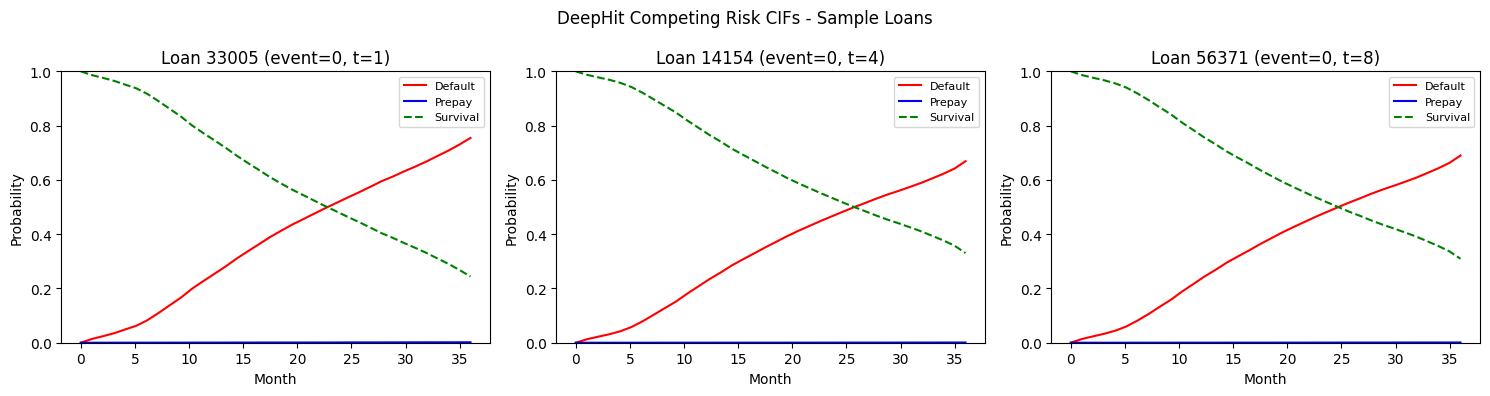

In [7]:
# ===== 6. VISUALIZE: Sample loan CIFs =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_grid = labtrans.cuts

for i, ax in enumerate(axes):
    idx = np.random.randint(len(x_test))
    ax.plot(time_grid, cif[0][:, idx], label='Default', color='red')
    ax.plot(time_grid, cif[1][:, idx], label='Prepay', color='blue')
    ax.plot(time_grid, 1 - cif[0][:, idx] - cif[1][:, idx], label='Survival', color='green', ls='--')
    ax.set_xlabel('Month')
    ax.set_ylabel('Probability')
    ax.set_title(f'Loan {idx} (event={y_test_evt[idx]}, t={y_test_dur[idx]})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('DeepHit Competing Risk CIFs - Sample Loans')
plt.tight_layout()
plt.show()